In [1]:
import sys
sys.path.append("/Users/sophia/Desktop/Fundamentals_of_Bioinformatics/BioInfoFinalProject")

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import seaborn as sns
import scanpy as sc
import warnings
warnings.filterwarnings("ignore", category = UserWarning, module = "openpyxl")
from trajectory_inference.Laplacian_Eigenmaps import fullLaplacian, scoreCells
adata = ad.read_h5ad("../data/wt_data.h5ad")

Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Embedding shape (1029, 2)
Pseudotime range -3.141161646681435 3.1350993127492437
Eigenvalues: [0.07382296 0.10627053]


Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...


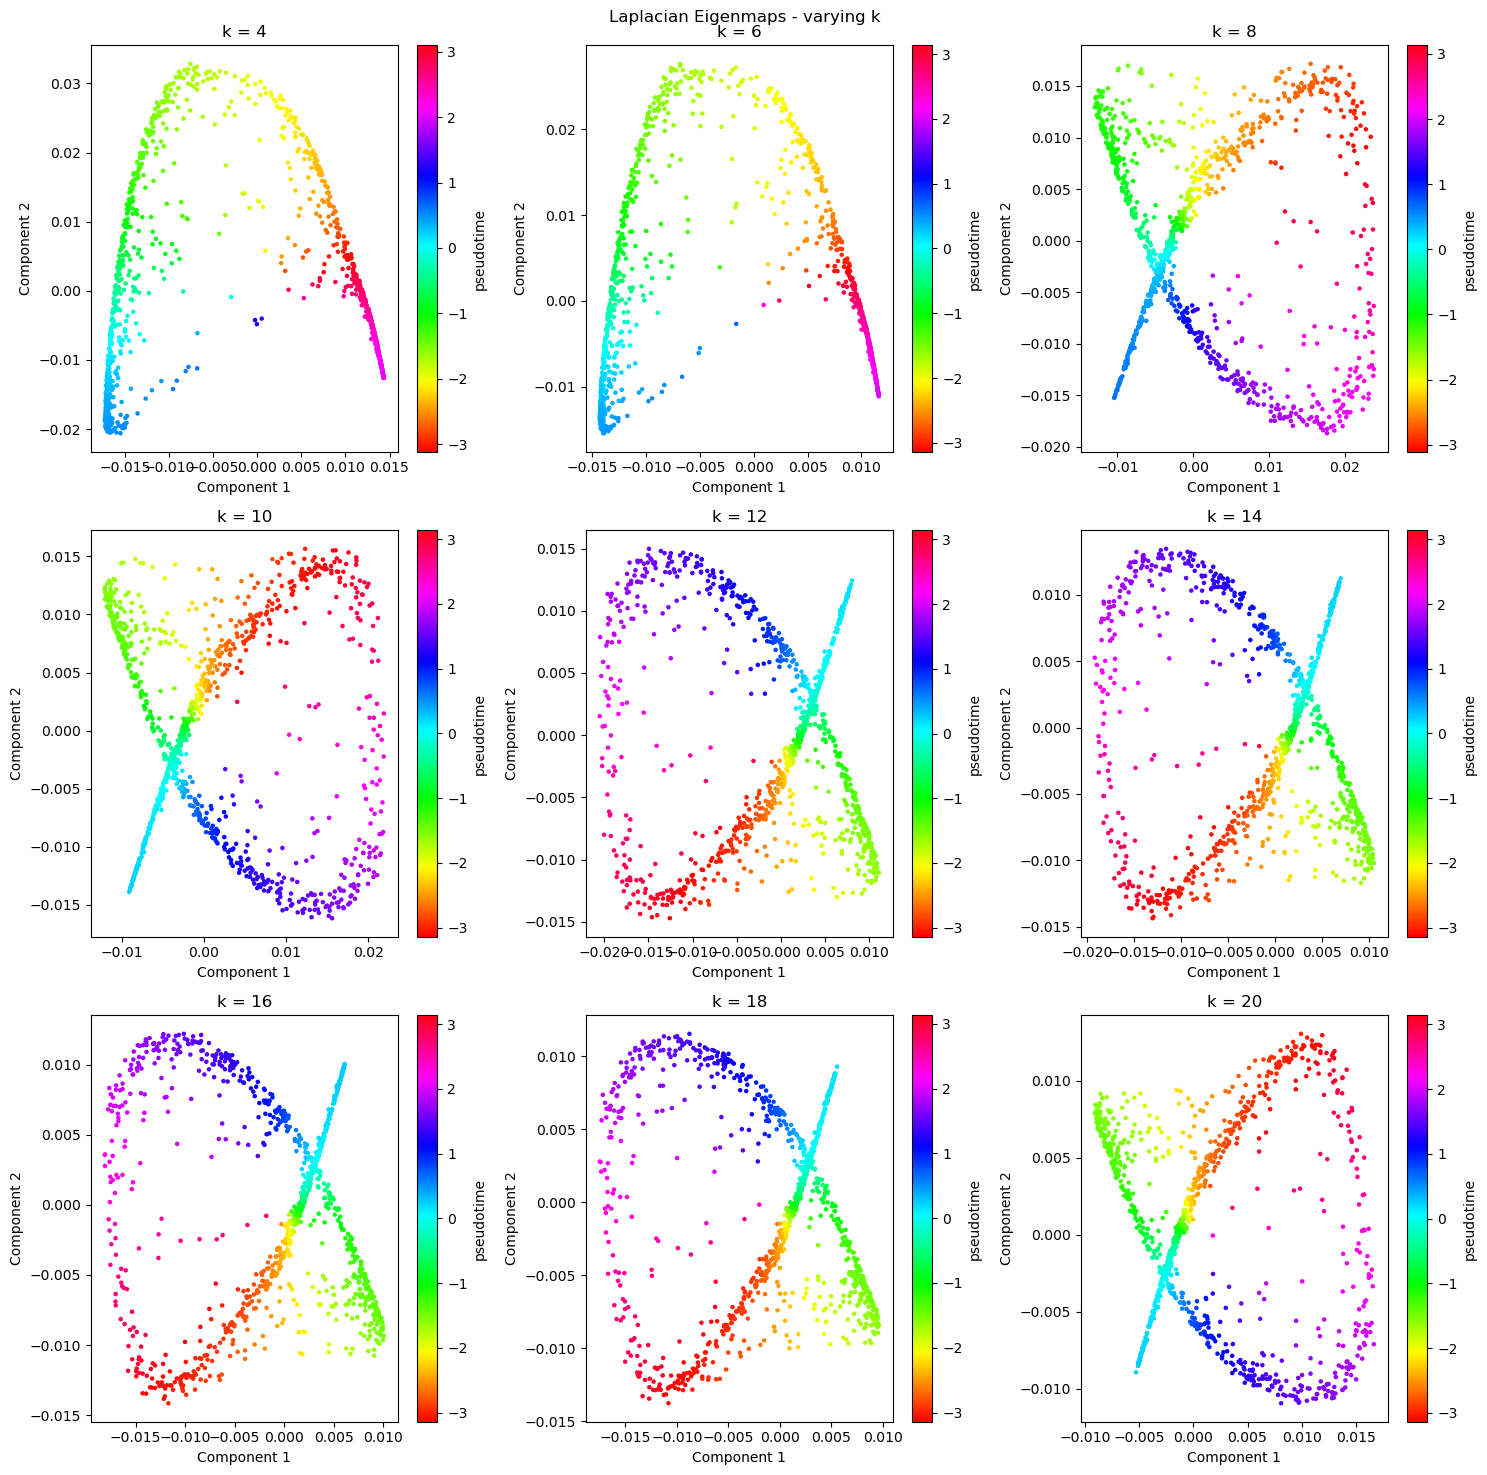

In [3]:
# checking plots with varying k clusters in kNN

kVals = list(range(4, 22, 2))
fig, axes = plt.subplots(3, 3, figsize = (15, 15))
axes = axes.flatten()

for i, k in enumerate(kVals):
    embeddings, eigvals, ps = fullLaplacian(adata, k = k)
    sc = axes[i].scatter(embeddings[:, 0], embeddings[:, 1], c = ps, cmap = "hsv", s = 5)
    axes[i].set_title(f"k = {k}")
    axes[i].set_xlabel("Component 1")
    axes[i].set_ylabel("Component 2")
    plt.colorbar(sc, ax = axes[i], label = "pseudotime")

plt.suptitle("Laplacian Eigenmaps - varying k")
plt.tight_layout()
plt.show()

Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...


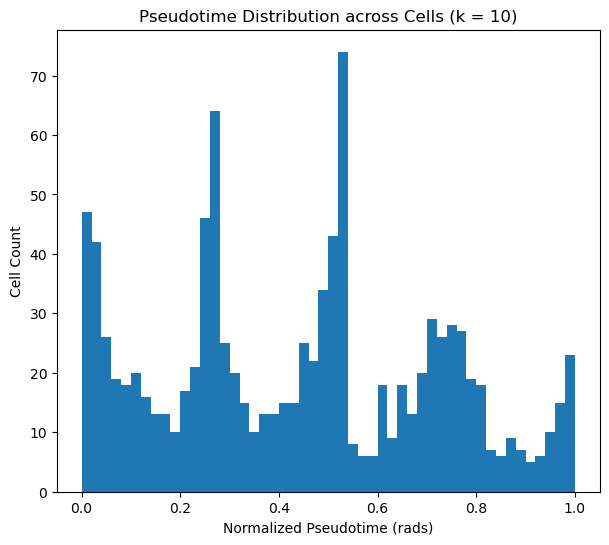

In [14]:
# plot of pseudotime distribution
embeddings, eigvals, pseudo = fullLaplacian(adata, k = 10)
pseudoNorm = (pseudo - pseudo.min()) / (pseudo.max() - pseudo.min())

plt.figure(figsize = (7, 6))
plt.hist(pseudoNorm, bins = 50)
plt.xlabel("Normalized Pseudotime (rads)")
plt.ylabel("Cell Count")
plt.title(f"Pseudotime Distribution across Cells (k = 10)")
plt.show()

/var/folders/dw/g18q38015s903bx123vgtd5c0000gn/T/ipykernel_78347/586715029.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = plotDF, x = "pseudotime", y = "phase", order = phases, palette = "Set1", ax = ax)


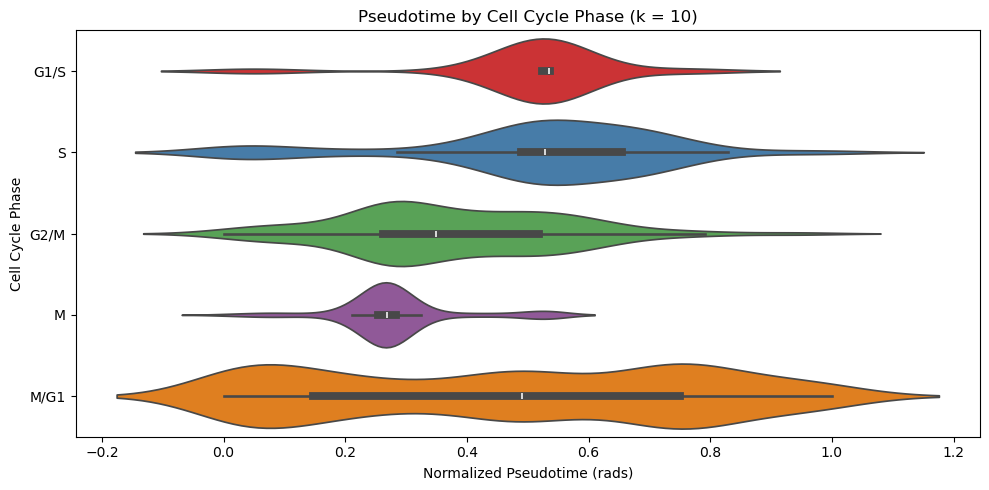

In [15]:
# plot showing cells in each cycle and corresponding pseudotime of cells

# reading in file with gene data for phases
xl = pd.ExcelFile("../data/GSE142277/gene_sets_GSE142277.xlsx")
geneSets = xl.parse("Gene Sets Used in Analysis")
phases = ["G1/S", "S", "G2/M", "M", "M/G1"]

# scoring cells based on phase marker expression and getting phase assignment
scoredAdata = scoreCells(adata, geneSets, phases)

# making dataframe with pseudotime and phase assignment of each cell
plotDF = pd.DataFrame({"pseudotime": pseudoNorm, "phase": adata.obs["phase"].values})

# violin plot pseudotime vs cell cycle phase
fig, ax = plt.subplots(figsize = (10, 5))
sns.violinplot(data = plotDF, x = "pseudotime", y = "phase", order = phases, palette = "Set1", ax = ax)
ax.set_xlabel("Normalized Pseudotime (rads)")
ax.set_ylabel("Cell Cycle Phase")
ax.set_title("Pseudotime by Cell Cycle Phase (k = 10)")
plt.tight_layout()
plt.show()

In [16]:
# Number of cells assigned to each phase

print("Number of cells in each phase\n")
print(scoredAdata.obs["phase"].value_counts())
scoreCols = [f"score_{p}" for p in phases]
print("-" * 60)

# mean score margin (avg difference between assigned phase score and second highest scored phase
# for each cell)
print("Mean score margin per phase\n")
scoredAdata.obs["score_margin"] = scoredAdata.obs[scoreCols].max(axis=1) - scoredAdata.obs[scoreCols].apply(lambda x: x.nlargest(2).iloc[-1], axis=1)
print(scoredAdata.obs.groupby("phase")["score_margin"].mean())

Number of cells in each phase

phase
M/G1    612
G2/M    157
S       122
M       121
G1/S     17
Name: count, dtype: int64
------------------------------------------------------------
Mean score margin per phase

phase
G1/S    0.013420
S       0.061155
G2/M    0.071110
M       0.088942
M/G1    0.145845
Name: score_margin, dtype: float64


/var/folders/dw/g18q38015s903bx123vgtd5c0000gn/T/ipykernel_78347/2742998242.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(scoredAdata.obs.groupby("phase")["score_margin"].mean())
